<a href="https://colab.research.google.com/github/aberno2000/course_practices/blob/main/practical_task_10_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import xgboost as xgb



df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "younusmohamed/particle-physics-event-classification-dataset", path="Particle Physics Event Classification.csv" )


Using Colab cache for faster access to the 'particle-physics-event-classification-dataset' dataset.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   EventId                      250000 non-null  int64  
 1   DER_mass_MMC                 250000 non-null  float64
 2   DER_mass_transverse_met_lep  250000 non-null  float64
 3   DER_mass_vis                 250000 non-null  float64
 4   DER_pt_h                     250000 non-null  float64
 5   DER_deltaeta_jet_jet         250000 non-null  float64
 6   DER_mass_jet_jet             250000 non-null  float64
 7   DER_prodeta_jet_jet          250000 non-null  float64
 8   DER_deltar_tau_lep           250000 non-null  float64
 9   DER_pt_tot                   250000 non-null  float64
 10  DER_sum_pt                   250000 non-null  float64
 11  DER_pt_ratio_lep_tau         250000 non-null  float64
 12  DER_met_phi_centrality       250000 non-null  float64
 13 

In [ ]:
df.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,9.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


In [ ]:
df.shape

(250000, 33)

In [ ]:
missing_mask = df.eq(-999.0)
rows_with_missing = missing_mask.any(axis=1)

df_clean = df[~rows_with_missing].copy() # removed -999 rows, small statistic
df_clean.shape

df_nan = df.copy()
df_nan = df_nan.replace(-999.0, np.nan)  # zeroed -999 values, mb wrong correlation

In [ ]:
df_nan['Label'] = df_nan['Label'].map({'s': True, 'b': False})
df_nan = df_nan.drop('EventId', axis=1)

df_clean['Label'] = df_clean['Label'].map({'s': True, 'b': False})
df_clean = df_clean.drop('EventId', axis=1)

In [ ]:
df_clean.head(100)

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,138.470,51.655,97.827,27.980,0.910,124.711,2.666,3.064,41.928,197.760,...,2,67.435,2.150,0.444,46.062,1.240,-2.475,113.497,0.002653,True
5,89.744,13.550,59.149,116.344,2.636,284.584,-0.540,1.362,61.619,278.876,...,3,90.547,-2.412,-0.653,56.165,0.224,3.106,193.660,0.083414,False
6,148.754,28.862,107.782,106.130,0.733,158.359,0.113,2.941,2.545,305.967,...,2,123.010,0.864,1.450,56.867,0.131,-2.767,179.877,0.002653,True
11,114.744,10.286,75.712,30.816,2.563,252.599,-1.401,2.888,36.745,239.804,...,3,76.773,-0.790,0.303,56.876,1.773,-2.079,165.640,0.307170,False
23,141.481,0.736,111.581,174.075,1.955,364.344,-0.923,1.335,6.663,440.859,...,2,195.533,1.156,1.416,82.477,-0.798,-2.785,278.009,0.001503,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,92.945,12.796,69.182,128.607,3.805,842.146,-3.078,1.273,33.609,441.513,...,3,217.017,1.167,1.736,70.039,-2.638,-0.849,321.166,0.307170,False
372,133.594,66.060,101.260,13.499,0.313,104.836,5.894,2.607,9.843,208.510,...,2,55.965,-2.589,1.698,47.442,-2.276,-1.601,103.407,1.954404,False
377,125.750,9.241,65.106,88.021,0.465,89.542,-0.046,1.974,23.957,190.839,...,2,75.676,-0.141,0.011,32.685,0.323,-2.068,108.361,0.002653,True
383,70.582,12.478,43.687,77.321,4.770,589.691,-5.524,1.546,39.166,177.606,...,2,75.816,1.979,1.230,39.403,-2.792,1.820,115.219,0.073899,False


In [ ]:
features_to_normalize = [
    # Mass features (different scales)
    'DER_mass_MMC',
    'DER_mass_transverse_met_lep',
    'DER_mass_vis',
    'DER_mass_jet_jet',

    # Momentum/Energy features (large dynamic range)
    'DER_pt_h',
    'DER_pt_tot',
    'DER_sum_pt',
    'PRI_tau_pt',
    'PRI_lep_pt',
    'PRI_met',
    'PRI_met_sumet',
    'PRI_jet_leading_pt',
    'PRI_jet_subleading_pt',
    'PRI_jet_all_pt',

    # Ratio features (could benefit from scaling)
    'DER_pt_ratio_lep_tau'
]

In [ ]:
def weighted_standard_scaler(X, weights):
    """Weighted standardization: (X - weighted_mean) / weighted_std"""
    weighted_mean = np.average(X, weights=weights, axis=0)
    weighted_variance = np.average((X - weighted_mean)**2, weights=weights, axis=0)
    weighted_std = np.sqrt(weighted_variance)
    return (X - weighted_mean) / weighted_std

X_to_normalize = df_nan[features_to_normalize].copy()
weights = df_nan['Weight'].values


from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_to_normalize)

# Apply weighted normalization
X_normalized = weighted_standard_scaler(X_imputed, weights)

# Replace in dataframe
for i, col in enumerate(features_to_normalize):
    df_nan[col] = X_normalized[:, i]

In [ ]:
X = df_nan.drop(['Label', 'Weight'], axis=1)  # Features
y = df_nan['Label']  # Target (True/False for s/b)
weights = df_nan['Weight']

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Convert back to DataFrame
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

# Split data with stratification and preserving weights
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X_imputed, y, weights, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',  # For binary classification
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',  # Binary classification metric
    scale_pos_weight=len(y_train[y_train == False]) / len(y_train[y_train == True])  # Handle class imbalance
)

# Train the model (without weights first)
xgb_classifier.fit(X_train, y_train)
print('')

# Make predictions
y_pred = xgb_classifier.predict(X_test)
y_pred_proba = xgb_classifier.predict_proba(X_test)[:, 1]  # Probability of class 1 (signal)

In [ ]:
print("Basic XGBoost Performance:")
print("=" * 50)
#print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Background (b)', 'Signal (s)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Basic XGBoost Performance:
ROC AUC: 0.9076

Classification Report:
                precision    recall  f1-score   support

Background (b)       0.90      0.83      0.86     32867
    Signal (s)       0.71      0.83      0.76     17133

      accuracy                           0.83     50000
     macro avg       0.81      0.83      0.81     50000
  weighted avg       0.84      0.83      0.83     50000


Confusion Matrix:
[[27134  5733]
 [ 2980 14153]]


In [ ]:
# XGBoost with event weights
xgb_weighted = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=np.sum(weights_train[y_train == False]) / np.sum(weights_train[y_train == True])  # Weight-aware class balance
)

# Train with sample weights
xgb_weighted.fit(
    X_train, y_train,
    sample_weight=weights_train,
    eval_set=[(X_test, y_test)],
    sample_weight_eval_set=[weights_test],
    verbose=False
)

# Weighted predictions
y_pred_weighted = xgb_weighted.predict(X_test)
y_pred_proba_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

In [ ]:
# Weighted accuracy (approximate)
weighted_accuracy = np.average(y_pred_weighted == y_test, weights=weights_test)
print(f"\nWeighted Accuracy: {weighted_accuracy:.4f}")
print(f"Weighted ROC AUC: {roc_auc_score(y_test, y_pred_proba_weighted, sample_weight=weights_test):.4f}")

print("\nWeighted Classification Report:")
print(classification_report(y_test, y_pred_weighted, target_names=['Background (b)', 'Signal (s)']))


Weighted Accuracy: 0.8378
Weighted ROC AUC: 0.9329

Weighted Classification Report:
                precision    recall  f1-score   support

Background (b)       0.92      0.74      0.82     32867
    Signal (s)       0.64      0.88      0.74     17133

      accuracy                           0.79     50000
     macro avg       0.78      0.81      0.78     50000
  weighted avg       0.82      0.79      0.79     50000



<Figure size 1200x800 with 0 Axes>

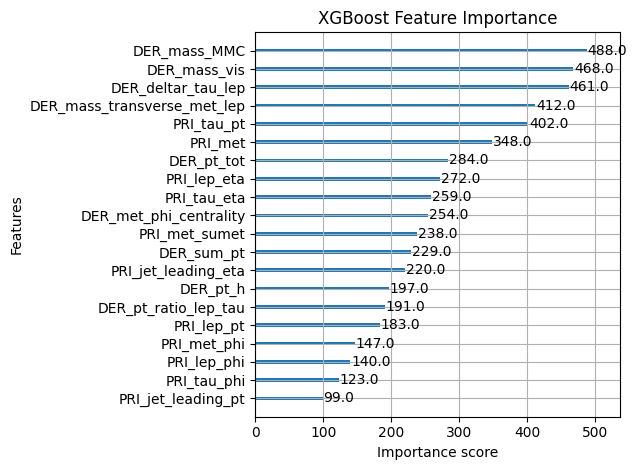


Top 10 Most Important Features:
                        feature  importance
1   DER_mass_transverse_met_lep    0.314515
0                  DER_mass_MMC    0.096877
11       DER_met_phi_centrality    0.086636
2                  DER_mass_vis    0.076822
13                   PRI_tau_pt    0.071049
10         DER_pt_ratio_lep_tau    0.058099
7            DER_deltar_tau_lep    0.037990
19                      PRI_met    0.035999
4          DER_deltaeta_jet_jet    0.020586
9                    DER_sum_pt    0.017570


In [ ]:
# Plot feature importance
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_weighted, max_num_features=20, importance_type='weight')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Get feature importance as dataframe
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_weighted.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))